# 01 · Объектная сегментация: интерактивные эксперименты

**Шесть стендов, 25 микрозаданий.** Полный маршрут с записями и обсуждением — около 60–75 минут.
Перед каждым опытом: **прогноз → настройки → результат → объяснение**. Заполняйте таблицу
под стендом; одного скриншота без настроек и вывода недостаточно. Код демо разрешается
использовать в основной работе. Служебные ячейки свёрнуты, но доступны для изучения.

Выполните **Run → Run All Cells** один раз. Затем меняйте элементы управления под рисунками.
Пересчёт происходит после отпускания ползунка. Звёздочка `[*]` означает, что ядро ещё занято.
Подготовка данных и двух моделей выполняется перед стендом 5; первые четыре стенда синтетические.
Каждый стенд также можно вызвать обычной функцией, указав аргументы в ячейке.

## Среда и данные

Запускайте ячейки сверху вниз. Для первого запуска нужен интернет: Penn–Fudan ≈52 MiB,
веса Mask R-CNN ≈170 MiB и YOLO11n-seg ≈6 MiB. Код содержит все функции и работает
без соседних файлов. Загрузки проверяются по SHA-256. Веса и результаты сохраняются
в `segmentation_lab_data`, которую не нужно сдавать целиком.

Локально используйте окружение предыдущей работы. В Colab загрузите этот `.ipynb`
через **Файл → Открыть блокнот → Загрузить**. Для обучения включите GPU до импортов.
Демо работает на CPU. Размер входа здесь учебный, 320 пикселей; Mask R-CNN сохраняет
пропорции с ограничением длинной стороны 512, YOLO использует letterbox.

Данные: 170 изображений, 423 размеченных человека; фиксированный split **120 / 25 / 25**, seed 42.
Это знакомый класс `person`, уже присутствующий в COCO, а не обучение новой категории.
ID экземпляра имеет смысл внутри одного изображения и не является ID человека между кадрами.
Некоторые фоновые люди не размечены. FP означает ошибку относительно доступной разметки;
в отчёте отличайте её неполноту от ошибки модели. Split сделан по изображениям, а не независимым сценам.

In [ ]:
# Сохраняем установленную пару PyTorch/torchvision, включая сборку CUDA.
import importlib.metadata as meta
import subprocess, sys
packages=['ultralytics==8.4.102','numpy>=1.26,<3','pandas>=2.1,<4',
          'matplotlib>=3.8,<4','Pillow>=10,<13','ipywidgets>=8.1,<9']
try:
    ready=meta.version('ultralytics')=='8.4.102'
    for name in ['torch','torchvision','numpy','pandas','matplotlib','Pillow','ipywidgets']:meta.version(name)
except meta.PackageNotFoundError:ready=False
if not ready:
    for name in ['torch','torchvision']:
        try:packages.append(name+'=='+meta.version(name))
        except meta.PackageNotFoundError:pass
    subprocess.check_call([sys.executable,'-m','pip','install','-q',*packages])
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:pass
print('Библиотеки готовы. Если они уже были импортированы до установки, перезапустите ядро.')

In [ ]:
"""Shared cells embedded into the distributed notebooks by build_segmentation.py."""
from pathlib import Path
import os, json, time, hashlib, urllib.request, shutil, zipfile, random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import torch
import torchvision
import cv2
import ultralytics
from ultralytics import YOLO
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


def fetch(url, path, expected):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and sha256_file(path) == expected:
        return path
    part = path.with_suffix(path.suffix + '.part')
    try:
        request = urllib.request.Request(url, headers={'User-Agent': 'SegmentationLab/1.0'})
        with urllib.request.urlopen(request, timeout=90) as source, part.open('wb') as out:
            shutil.copyfileobj(source, out)
        if sha256_file(part) != expected:
            raise ValueError('Контрольная сумма не совпала: ' + path.name)
        part.replace(path)
    except Exception:
        part.unlink(missing_ok=True)
        raise
    return path


WEIGHT_SOURCES = {
    'maskrcnn': ('https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth',
                'maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth',
                'bf2d0c1efbc936eeee2bc95a48e80ebc86b891f61b0106485937fc29f9315fc0'),
    'yolo11n_seg': ('https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt',
                    'yolo11n-seg.pt',
                    '55ed65c56c91713d23e8402371c6c49a6fd84f257f7dce452e8d70e41dcbe152'),
}
DATA_SHA = '9095a9613c95586f1c7f2a327d454833d16e0f5e17e5f83d35027ffd315b48e2'


def prepare_data(root):
    root = Path(root); root.mkdir(parents=True, exist_ok=True)
    archive = fetch('https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip', root/'PennFudanPed.zip', DATA_SHA)
    data = root/'PennFudanPed'
    if not (data/'.segmentation_extracted').exists():
        with zipfile.ZipFile(archive) as z:
            for m in z.infolist():
                if not (root/m.filename).resolve().is_relative_to(root.resolve()):
                    raise ValueError('Некорректный путь в архиве')
            z.extractall(root)
        (data/'.segmentation_extracted').touch()
    paths = sorted((data/'PNGImages').glob('*.png'))
    assert len(paths) == 170
    items = [{'name':p.name, 'image':p, 'mask':data/'PedMasks'/(p.stem+'_mask.png')} for p in paths]
    order = np.random.default_rng(42).permutation(len(items))
    split = {k:[items[i] for i in ix] for k,ix in [('train',order[:120]),('val',order[120:145]),('test',order[145:])]}
    manifest = {k:[s['name'] for s in v] for k,v in split.items()}
    (root/'split_seed42.json').write_text(json.dumps(manifest, indent=2))
    assert len(set(sum(manifest.values(), []))) == 170
    return split


def read_sample(item):
    with Image.open(item['image']) as im: image = np.array(im.convert('RGB'))
    with Image.open(item['mask']) as im: labels = np.array(im)
    return image, labels


def weight_path(key):
    url, name, sha = WEIGHT_SOURCES[key]
    return fetch(url, ROOT/'weights'/name, sha)


def seed_all(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)


def make_maskrcnn(finetuned=False, checkpoint=None):
    # Без неявной загрузки backbone и без автоматического изменения числа классов.
    model = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None,
                                 min_size=320, max_size=512, box_score_thresh=.01,
                                 box_nms_thresh=.5, box_detections_per_img=30)
    if checkpoint is None:
        model.load_state_dict(torch.load(weight_path('maskrcnn'), map_location='cpu', weights_only=True))
    if finetuned:
        # person уже есть в COCO. Сохраняем строки background/person предобученных голов.
        old_box, old_mask = model.roi_heads.box_predictor, model.roi_heads.mask_predictor
        box = FastRCNNPredictor(old_box.cls_score.in_features, 2)
        mask = MaskRCNNPredictor(old_mask.conv5_mask.in_channels, 256, 2)
        if checkpoint is None:
            with torch.no_grad():
                box.cls_score.weight.copy_(old_box.cls_score.weight[:2]); box.cls_score.bias.copy_(old_box.cls_score.bias[:2])
                box.bbox_pred.weight.copy_(old_box.bbox_pred.weight[:8]); box.bbox_pred.bias.copy_(old_box.bbox_pred.bias[:8])
                mask.conv5_mask.load_state_dict(old_mask.conv5_mask.state_dict())
                mask.mask_fcn_logits.weight.copy_(old_mask.mask_fcn_logits.weight[:2]); mask.mask_fcn_logits.bias.copy_(old_mask.mask_fcn_logits.bias[:2])
        model.roi_heads.box_predictor, model.roi_heads.mask_predictor = box, mask
    if checkpoint is not None:
        model.load_state_dict(torch.load(checkpoint, map_location='cpu', weights_only=True))
    return model.to(DEVICE)


@torch.inference_mode()
def predict_maskrcnn(model, item):
    image, _ = read_sample(item)
    model.eval()
    result = model([torch.from_numpy(image.copy()).permute(2,0,1).float().to(DEVICE)/255])[0]
    keep = (result['labels']==1) & (result['scores']>=.01)
    return {'masks':result['masks'][keep,0].cpu().numpy(), 'scores':result['scores'][keep].cpu().numpy(),
            'boxes':result['boxes'][keep].cpu().numpy()}


def predict_yolo(model, item, finetuned=False):
    image, _ = read_sample(item)
    r = model.predict(image[:,:,::-1].copy(), imgsz=320, conf=.01, iou=.5,
                      max_det=30, classes=[0], retina_masks=True, device=DEVICE, verbose=False)[0]
    masks = np.zeros((0,*image.shape[:2]),dtype=np.float32) if r.masks is None else r.masks.data.cpu().numpy().astype(np.float32)
    # retina_masks возвращает бинарные маски в исходных H,W; это не вероятности.
    assert masks.shape[1:] == image.shape[:2]
    return {'masks':masks, 'scores':r.boxes.conf.cpu().numpy(), 'boxes':r.boxes.xyxy.cpu().numpy()}


def raster_boxes(boxes, shape):
    masks = np.zeros((len(boxes), *shape), dtype=bool)
    h,w = shape
    for m,b in zip(masks, boxes):
        x1,y1 = np.floor(b[:2]).astype(int); x2,y2 = np.ceil(b[2:]).astype(int)
        m[max(0,y1):min(h,y2),max(0,x1):min(w,x2)] = True
    return masks


def union_mask(masks, shape):
    return np.any(masks,axis=0) if len(masks) else np.zeros(shape,dtype=bool)


def show_masks(ax, image, masks, title, scores=None):
    ax.imshow(image)
    overlay = np.zeros((*image.shape[:2],4))
    for j,m in enumerate(masks):
        color = plt.get_cmap('tab20')(j%20)
        overlay[np.asarray(m,dtype=bool)] = (*color[:3],.48)
        ys,xs=np.where(m)
        if len(xs): ax.text(xs.mean(),ys.mean(),str(j+1)+(f' / {scores[j]:.2f}' if scores is not None else ''),color='white',fontsize=9,bbox={'facecolor':'black','alpha':.65,'pad':1})
    ax.imshow(overlay); ax.set_title(title); ax.axis('off')


def ap101(tp, scores, n_gt):
    if n_gt == 0: return float('nan')
    order=np.argsort(-np.asarray(scores),kind='stable'); tp=np.asarray(tp,dtype=float)[order]
    if not len(tp): return 0.
    recall=np.cumsum(tp)/n_gt; precision=np.cumsum(tp)/np.arange(1,len(tp)+1)
    return float(np.mean([precision[recall>=r].max(initial=0) for r in np.linspace(0,1,101)]))


def evaluate_predictions(items, predictions, conf=.25, mask_threshold=.5, as_boxes=False):
    # Общий оценщик для обоих методов. GT всегда исходные растровые маски.
    if len(items) != len(predictions) or not items:
        raise ValueError('Для каждого изображения нужен один результат; набор не должен быть пустым')
    tps={t:[] for t in [.5,.75]}; scores=[]; rows=[]; total_gt=0
    for item,p in zip(items,predictions):
        image, ids=read_sample(item); gt=instance_target(ids)['masks'].astype(bool)
        masks = raster_boxes(p['boxes'],ids.shape) if as_boxes else p['masks']>=mask_threshold
        total_gt+=len(gt); scores.extend(p['scores'].tolist())
        for t in tps: tps[t].extend((match_masks(gt,masks,p['scores'],t)>=0).tolist())
        take=p['scores']>=conf; matched=match_masks(gt,masks[take],p['scores'][take],.5)
        tp=int(np.sum(matched>=0)); fp=int(np.sum(matched<0)); fn=len(gt)-tp
        ug,up=union_mask(gt,ids.shape),union_mask(masks[take],ids.shape)
        inter=int(np.logical_and(ug,up).sum()); union=int(np.logical_or(ug,up).sum())
        dice=2*inter/max(1,int(ug.sum()+up.sum()))
        rows.append({'image':item['name'],'TP':tp,'FP':fp,'FN':fn,'foreground_IoU':inter/max(1,union),'foreground_Dice':dice})
    table=pd.DataFrame(rows); tp,fp,fn=table[['TP','FP','FN']].sum()
    metrics={'mask_AP50_above_001':ap101(tps[.5],scores,total_gt),
             'mask_AP75_above_001':ap101(tps[.75],scores,total_gt),
             'precision_025':float(tp/max(1,tp+fp)),'recall_025':float(tp/max(1,tp+fn)),
             'foreground_IoU_macro':float(table.foreground_IoU.mean()),'TP':int(tp),'FP':int(fp),'FN':int(fn)}
    return metrics,table


def predict_subset(key, checkpoint, items):
    start=time.perf_counter()
    model=make_maskrcnn(True,checkpoint) if key=='maskrcnn' else YOLO(str(checkpoint))
    params=sum(p.numel() for p in (model if key=='maskrcnn' else model.model).parameters())
    predictions=[predict_maskrcnn(model,item) if key=='maskrcnn' else predict_yolo(model,item,True) for item in items]
    if DEVICE!='cpu': torch.cuda.synchronize()
    elapsed=time.perf_counter()-start
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return predictions,elapsed,params

In [ ]:
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(min(4,os.cpu_count() or 1))
ROOT=Path(os.environ.get('SEGMENTATION_LAB_ROOT','segmentation_lab_data')).resolve()
ROOT.mkdir(parents=True,exist_ok=True)
seed_all(42)
print('Устройство:',DEVICE,'| torch',torch.__version__,'| torchvision',torchvision.__version__,'| ultralytics',ultralytics.__version__)

In [ ]:
def instance_target(id_map):
    """Карта H×W, 0=фон → masks[N,H,W], boxes[N,4], labels[N], area[N]."""
    id_map = np.asarray(id_map)
    if id_map.ndim != 2 or np.any(id_map < 0) or not np.issubdtype(id_map.dtype,np.integer):
        raise ValueError('Нужна неотрицательная целочисленная карта H×W')
    ids = np.unique(id_map); ids=ids[ids!=0]
    masks=(id_map[None,:,:]==ids[:,None,None]).astype(np.uint8)
    boxes=[]
    for m in masks:
        ys,xs=np.where(m)
        boxes.append([xs.min(),ys.min(),xs.max()+1,ys.max()+1])
    return {'masks':masks,'boxes':np.asarray(boxes,dtype=np.float32).reshape(-1,4),
            'labels':np.ones(len(ids),dtype=np.int64),'area':masks.sum((1,2)).astype(np.float32)}

def hflip_sample(image, target):
    """Новое изображение и новый target; не изменять исходные массивы."""
    width=image.shape[1]; out={k:v.copy() for k,v in target.items()}
    out['masks']=target['masks'][:,:,::-1].copy()
    out['boxes'][:,0]=width-target['boxes'][:,2]
    out['boxes'][:,2]=width-target['boxes'][:,0]
    return image[:,::-1].copy(),out

def mask_iou_matrix(a, b):
    """Bool-маски A×H×W, B×H×W → IoU A×B; union=0 даёт 0."""
    a,b=np.asarray(a,dtype=bool),np.asarray(b,dtype=bool)
    if a.ndim!=3 or b.ndim!=3 or a.shape[1:]!=b.shape[1:]:
        raise ValueError('Ожидаются маски N×H×W одинакового размера')
    flat_a=a.reshape(len(a),int(np.prod(a.shape[1:]))).astype(np.float32)
    flat_b=b.reshape(len(b),int(np.prod(b.shape[1:]))).astype(np.float32)
    intersection=flat_a@flat_b.T
    union=flat_a.sum(1)[:,None]+flat_b.sum(1)[None,:]-intersection
    return np.divide(intersection,union,out=np.zeros_like(intersection),where=union>0)

def match_masks(gt, pred, scores, iou_threshold=.5):
    """Индекс GT для каждого исходного предсказания либо -1. Один класс."""
    scores=np.asarray(scores,dtype=float)
    if len(pred)!=len(scores): raise ValueError('Число confidence не совпадает с числом масок')
    ious=mask_iou_matrix(pred,gt); result=np.full(len(pred),-1,dtype=np.int64)
    used=np.zeros(len(gt),dtype=bool)
    for j in np.argsort(-scores,kind='stable'):
        candidates=np.where(~used & (ious[j]>=iou_threshold))[0]
        if len(candidates):
            k=candidates[np.argmax(ious[j,candidates])];result[j]=k;used[k]=True
    return result

def assemble_masks(prototypes, coefficients, boxes):
    """P[K,H,W], C[N,K], полуоткрытые bbox[N,4] → probabilities[N,H,W]."""
    prototypes=np.asarray(prototypes,dtype=float);coefficients=np.asarray(coefficients,dtype=float)
    logits=np.einsum('nk,khw->nhw',coefficients,prototypes)
    probabilities=1/(1+np.exp(-np.clip(logits,-60,60)))
    h,w=prototypes.shape[1:];y,x=np.mgrid[:h,:w]
    for i,(x1,y1,x2,y2) in enumerate(boxes):
        crop=(x>=x1)&(x<x2)&(y>=y1)&(y<y2)
        probabilities[i]*=crop
    return probabilities

In [ ]:
"""Interactive stands: controls, calculations and visible evidence for each decision."""
import ipywidgets as widgets
from matplotlib.colors import ListedColormap


def stand_controls(function, **controls):
    # Explicit binding also works when the function's argument names differ from labels.
    for control in controls.values():
        if hasattr(control, 'continuous_update'): control.continuous_update = False
        control.style = {'description_width': '150px'}
        control.layout = widgets.Layout(width='440px')
    output = widgets.interactive_output(function, controls)
    display(widgets.VBox(list(controls.values()) + [output]))


def overlap_values(dx=3, background=64):
    gt=np.zeros((background,background),bool);pred=np.zeros_like(gt)
    gt[8:18,8:18]=True;pred[8:18,8+dx:18+dx]=True
    inter=int((gt&pred).sum());union=int((gt|pred).sum())
    return gt,pred,{'intersection':inter,'union':union,'FP_pixels':int((pred&~gt).sum()),
                   'FN_pixels':int((gt&~pred).sum()),'IoU':inter/max(1,union),
                   'Dice':2*inter/max(1,int(gt.sum()+pred.sum())),
                   'accuracy':float((gt==pred).mean())}


def overlap_demo(dx=3, background=64):
    gt,pred,m=overlap_values(dx,background)
    picture=np.zeros((*gt.shape,3));picture[gt]=(0.2,.55,1);picture[pred]=(1,.4,.15);picture[gt&pred]=(.5,.25,.8)
    fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].imshow(picture);axes[0].axis('off')
    axes[0].set_title(f'Сдвиг {dx}; поле {background} × {background}')
    axes[1].axis('off');axes[1].text(0,.95,
        f"GT: 100 пикселей; предсказание: 100\n\nПересечение: {m['intersection']}; объединение: {m['union']}\n"
        f"Лишние пиксели: {m['FP_pixels']}; пропущенные: {m['FN_pixels']}\n\n"
        f"IoU = {m['intersection']} / {m['union']} = {m['IoU']:.4f}\n"
        f"Dice = 2 × {m['intersection']} / 200 = {m['Dice']:.4f}\n"
        f"Accuracy = 1 − {m['FP_pixels']+m['FN_pixels']} / {background**2} = {m['accuracy']:.4f}",
        va='top',fontsize=12,linespacing=1.5)
    plt.tight_layout();plt.show()


def matching_case(mode='merge', shift=4):
    gt=np.zeros((2,32,56),bool);gt[0,8:25,6:24]=1;gt[1,8:25,24:42]=1
    if mode=='merge':pred=gt.any(0,keepdims=True);scores=np.array([.9])
    elif mode=='separate':pred=gt.copy();scores=np.array([.9,.8])
    elif mode=='shift':
        pred=np.zeros_like(gt)
        pred[0,8:25,6+shift:24+shift]=1;pred[1,8:25,24+shift:42+shift]=1
        scores=np.array([.9,.8])
    elif mode=='duplicate':pred=gt[[0,0,1]].copy();scores=np.array([.7,.9,.8])
    else:raise ValueError('Неизвестный случай')
    return gt,pred,scores


def matching_values(gt,pred,scores,match_iou=.5):
    ious=mask_iou_matrix(pred,gt);matches=match_masks(gt,pred,scores,match_iou)
    tp=int((matches>=0).sum());ug=gt.any(0);up=pred.any(0)
    fg=float((ug&up).sum()/max(1,int((ug|up).sum())))
    used=set();steps=[]
    for j in np.argsort(-scores,kind='stable'):
        k=int(matches[j]);eligible=np.flatnonzero(ious[j]>=match_iou)
        if k>=0:
            reason=f"P{j+1} → GT{k+1}: IoU={ious[j,k]:.3f} ≥ {match_iou:.2f}; TP"
            used.add(k)
        elif len(eligible):reason=f"P{j+1} → FP: подходящие GT уже заняты более уверенными предсказаниями"
        else:reason=f"P{j+1} → FP: лучший IoU={ious[j].max(initial=0):.3f} < {match_iou:.2f}"
        steps.append(f"score={scores[j]:.2f}: {reason}")
    missed=[f'GT{k+1}' for k in range(len(gt)) if k not in used]
    steps.append('FN: '+(', '.join(missed) if missed else 'нет'))
    return {'ious':ious,'matches':matches,'TP':tp,'FP':len(pred)-tp,'FN':len(gt)-tp,
            'foreground_IoU':fg,'steps':steps}


def merge_demo(mode='merge', match_iou=.75, shift=4):
    gt,pred,scores=matching_case(mode,shift);m=matching_values(gt,pred,scores,match_iou)
    image=np.full((*gt.shape[1:],3),225,np.uint8)
    fig=plt.figure(figsize=(13,6));grid=fig.add_gridspec(2,3,height_ratios=[3,1.7])
    axes=[fig.add_subplot(grid[0,i]) for i in range(3)]
    show_masks(axes[0],image,gt,'Разметка: GT1, GT2')
    show_masks(axes[1],image,pred,'Предсказания P1…; цвет — номер',scores)
    for i,t in enumerate(axes[0].texts):t.set_text(f'GT{i+1}')
    for i,t in enumerate(axes[1].texts):t.set_text(f'P{i+1} / {scores[i]:.2f}')
    if mode=='duplicate':
        axes[1].texts[0].set_position((14.5,12))
        axes[1].texts[1].set_position((14.5,21))
    ax=axes[2];ax.imshow(m['ious']>=match_iou,cmap=ListedColormap(['#eeeeee','#b9e4c9']),vmin=0,vmax=1,aspect='auto')
    for j in range(len(pred)):
        for k in range(len(gt)):
            chosen=m['matches'][j]==k
            ax.text(k,j,f"{m['ious'][j,k]:.3f}"+('\nПАРА' if chosen else ''),ha='center',va='center',fontsize=12)
            if chosen:ax.add_patch(plt.Rectangle((k-.48,j-.48),.96,.96,fill=False,edgecolor='#155a32',linewidth=3))
    ax.set(xticks=range(len(gt)),xticklabels=['GT1','GT2'],yticks=range(len(pred)),yticklabels=[f'P{i+1}' for i in range(len(pred))],title=f'IoU ≥ {match_iou:.2f}: зелёные ячейки')
    log=fig.add_subplot(grid[1,:]);log.axis('off')
    log.text(0,1,'\n'.join(m['steps']),va='top',fontsize=11,linespacing=1.55)
    fig.suptitle(f"TP={m['TP']} · FP={m['FP']} · FN={m['FN']} · foreground IoU={m['foreground_IoU']:.3f}",fontsize=15)
    fig.text(.02,.015,'Порог меняет допустимые пары и счётчики. Маски остаются прежними. Один GT — не более одной пары.',fontsize=10)
    fig.tight_layout(rect=[0,.055,1,.94]);plt.show()


def roi_values(x=.25, y=.5, f11=8):
    values=np.array([[2.,4.],[6.,float(f11)]])
    weights=np.array([[(1-x)*(1-y),x*(1-y)],[(1-x)*y,x*y]])
    return {'values':values,'weights':weights,'value':float((values*weights).sum()),
            'nearest':float(values[int(y>=.5),int(x>=.5)]),
            'top':float((1-x)*2+x*4),'bottom':float((1-x)*6+x*f11)}


def roi_demo(x=.25, y=.5, f11=8):
    r=roi_values(x,y,f11);fig,ax=plt.subplots(figsize=(9,7));fig.subplots_adjust(bottom=.39,top=.91)
    ax.set(xlim=(-.25,1.25),ylim=(1.25,-.25),xticks=[0,1],yticks=[0,1],xlabel='x',ylabel='y');ax.set_aspect('equal')
    for j in range(2):
        for i in range(2):
            ax.scatter(i,j,s=650,c='#3631ab');ax.text(i,j,f'{r["values"][j,i]:g}',ha='center',va='center',color='white',fontsize=13)
            ax.annotate(f'f{i}{j}; вес {r["weights"][j,i]:.3f}',(i,j),xytext=(0,-26 if j else 19),textcoords='offset points',ha='center',fontsize=10)
    ax.scatter(x,y,c='orange',edgecolor='black',s=170,zorder=5);ax.grid(alpha=.2)
    ax.set_title(f"x={x:.2f}, y={y:.2f}: билинейно {r['value']:.3f}; ближайший узел {r['nearest']:g}")
    fig.text(.04,.30,r'$F(x,y)=(1-x)(1-y)f_{00}+x(1-y)f_{10}+(1-x)yf_{01}+xyf_{11}$',fontsize=13)
    w=r['weights'].ravel();v=r['values'].ravel()
    fig.text(.04,.24,'F = '+' + '.join(f'{a:.3f} × {b:g}' for a,b in zip(w,v))+f" = {r['value']:.3f}",fontsize=12)
    fig.text(.04,.17,f"Сначала по x: верх = (1−{x:.2f})×2 + {x:.2f}×4 = {r['top']:.3f}\n"
             f"                        низ = (1−{x:.2f})×6 + {x:.2f}×{f11:g} = {r['bottom']:.3f}",fontsize=12,linespacing=1.5)
    fig.text(.04,.085,f"Затем по y: F = (1−{y:.2f})×{r['top']:.3f} + {y:.2f}×{r['bottom']:.3f} = {r['value']:.3f}",fontsize=12)
    fig.text(.04,.035,f"Сумма весов = {w.sum():.3f}. Координаты внутри одной ячейки карты признаков; это одна выборка RoIAlign.",fontsize=10)
    plt.show()


def prototype_values(first=1., second=0., third=0., threshold=.5, target='both', crop='full'):
    y,x=np.mgrid[:64,:96];left=np.zeros((64,96),bool);right=left.copy()
    for mask,cx in [(left,27),(right,69)]:
        mask|=((x-cx)**2+(y-12)**2<=7**2)
        mask|=((abs(x-cx)<=12)&(y>=21)&(y<58))
    holes=(((abs(x-27)<=3)|(abs(x-69)<=3))&(y>=40)&(y<58))&(left|right)
    prototypes=np.stack([np.where(left|right,4.,-4.),4.*left-4.*right,12.*holes])
    truth={'both':(left|right)&~holes,'left':left&~holes,'right':right&~holes}[target]
    bbox={'full':[0,0,96,64],'left':[12,3,42,60],'narrow':[21,3,34,60]}[crop]
    coeff=np.array([[first,second,third]],float);logits=np.einsum('nk,khw->nhw',coeff,prototypes)[0]
    probabilities=assemble_masks(prototypes,coeff,np.array([bbox]))[0];pred=probabilities>=threshold
    tp=pred&truth;fp=pred&~truth;fn=~pred&truth
    iou=float(tp.sum()/max(1,int((pred|truth).sum())))
    return {'prototypes':prototypes,'coefficients':coeff[0],'truth':truth,'bbox':bbox,'logits':logits,
            'probabilities':probabilities,'pred':pred,'TP':tp,'FP':fp,'FN':fn,'IoU':iou}


def prototype_demo(first=1., second=0., third=0., threshold=.5, target='both', crop='full'):
    r=prototype_values(first,second,third,threshold,target,crop)
    fig,axes=plt.subplots(2,3,figsize=(13,8));fig.subplots_adjust(bottom=.2,wspace=.25,hspace=.35,top=.90)
    titles=['P₁: общий силуэт и отрицательный фон','P₂: разделение левой и правой фигур','P₃: области между ногами']
    for ax,p,title in zip(axes[0],r['prototypes'],titles):
        im=ax.imshow(p,cmap='coolwarm',vmin=-12,vmax=12);ax.set_title(title,fontsize=10);fig.colorbar(im,ax=ax,fraction=.035,pad=.02)
    im=axes[1,0].imshow(r['logits'],cmap='coolwarm',vmin=-16,vmax=16);fig.colorbar(im,ax=axes[1,0],fraction=.035,pad=.02);axes[1,0].set_title('Логит: c₁P₁ + c₂P₂ + c₃P₃')
    im=axes[1,1].imshow(r['probabilities'],cmap='viridis',vmin=0,vmax=1);fig.colorbar(im,ax=axes[1,1],fraction=.035,pad=.02);axes[1,1].set_title('Sigmoid, затем crop')
    comparison=np.ones((*r['truth'].shape,3))*.93;comparison[r['TP']]=(.1,.65,.35);comparison[r['FP']]=(.95,.2,.2);comparison[r['FN']]=(1,.65,.1)
    axes[1,2].imshow(comparison);axes[1,2].set_title(f'Порог {threshold:.2f}; IoU с целью {r["IoU"]:.3f}')
    for ax in axes.flat:ax.axis('off')
    for ax in axes[1]:
        x1,y1,x2,y2=r['bbox'];ax.add_patch(plt.Rectangle((x1-.5,y1-.5),x2-x1,y2-y1,fill=False,edgecolor='#111111',linewidth=1.5))
    points={'A':(27,30),'B':(27,48),'C':(69,30),'D':(8,30)}
    for label,(px,py) in points.items():
        axes[0,0].text(px,py,label,color='black',ha='center',va='center',fontsize=10,bbox={'facecolor':'white','pad':1,'alpha':.8})
    fig.suptitle(f'Цель: { {"both":"две фигуры","left":"левая фигура","right":"правая фигура"}[target]}; c=({first:g}, {second:g}, {third:g})',fontsize=14)
    fig.text(.03,.125,'Точки A/B/C/D: '+ '; '.join(f'{label}: z={r["logits"][py,px]:g}, p={r["probabilities"][py,px]:.3f}' for label,(px,py) in points.items()),fontsize=10)
    fig.text(.03,.08,f"Зелёный — верные пиксели ({r['TP'].sum()}); красный — лишние ({r['FP'].sum()}); оранжевый — пропущенные ({r['FN'].sum()}).",fontsize=11)
    fig.text(.03,.035,'Цель меняет только разметку для проверки. Три коэффициента, порог и рамка меняют предсказание. Решающее правило: p ≥ порога.',fontsize=10)
    plt.show()


def threshold_demo(item, prediction, confidence=.5, mask_threshold=.5):
    image,ids=read_sample(item);gt=instance_target(ids)['masks'].astype(bool);take=prediction['scores']>=confidence
    masks=prediction['masks'][take]>=mask_threshold;boxes=raster_boxes(prediction['boxes'][take],ids.shape)
    scores=prediction['scores'][take];m=matching_values(gt,masks,scores,.5);b=matching_values(gt,boxes,scores,.5)
    fig,axes=plt.subplots(1,3,figsize=(14,5))
    show_masks(axes[0],image,gt,f'GT: {len(gt)} экземпляров')
    show_masks(axes[1],image,boxes,f'Рамки: foreground IoU={b["foreground_IoU"]:.3f}',scores)
    show_masks(axes[2],image,masks,f"Маски: TP {m['TP']}, FP {m['FP']}, FN {m['FN']}\nforeground IoU={m['foreground_IoU']:.3f}",scores)
    # IDs remain stable across confidence settings.
    original_ids=np.flatnonzero(take)+1
    for ax in axes[1:]:
        nonempty=[j for j,mask in enumerate(boxes if ax is axes[1] else masks) if mask.any()]
        for text,j in zip(ax.texts,nonempty):text.set_text(f'P{original_ids[j]} / {scores[j]:.2f}')
    fig.suptitle(f'confidence ≥ {confidence:.2f}; пиксель ≥ {mask_threshold:.2f}; кандидатов {len(masks)}; пикселей {masks.sum()}')
    plt.tight_layout();plt.show()
    rows=[]
    for j,pid in enumerate(original_ids):
        k=m['matches'][j]
        rows.append({'ID':f'P{pid}','score':round(float(scores[j]),4),'площадь':int(masks[j].sum()),
                     'лучший IoU':round(float(m['ious'][j].max(initial=0)),4),
                     'пара':f'GT{k+1}' if k>=0 else '—','статус':'TP' if k>=0 else 'FP'})
    display(pd.DataFrame(rows,columns=['ID','score','площадь','лучший IoU','пара','статус']))
    print('Формы масок и таблица пересчитаны из сохранённых вероятностей. Модель и NMS повторно не запускались. MATCH IoU = 0.50.')


def real_comparison(item, maskrcnn_prediction, yolo_prediction, conf_mask=.25, conf_yolo=.25, match_iou=.5):
    image,ids=read_sample(item);gt=instance_target(ids)['masks'].astype(bool)
    fig,axes=plt.subplots(1,3,figsize=(14,5));show_masks(axes[0],image,gt,f'GT: {len(gt)} экземпляров');rows=[]
    for ax,p,title,conf in [(axes[1],maskrcnn_prediction,'Mask R-CNN',conf_mask),(axes[2],yolo_prediction,'YOLO11n-seg',conf_yolo)]:
        take=p['scores']>=conf;masks=p['masks'][take]>=.5;m=matching_values(gt,masks,p['scores'][take],match_iou)
        show_masks(ax,image,masks,f"{title} · conf={conf:.2f}\nTP {m['TP']} / FP {m['FP']} / FN {m['FN']}",p['scores'][take])
        rows.append({'модель':title,'conf':conf,'N':len(masks),'TP':m['TP'],'FP':m['FP'],'FN':m['FN'],
                     'precision':m['TP']/max(1,len(masks)),'recall':m['TP']/max(1,len(gt)),'foreground IoU':m['foreground_IoU']})
    fig.suptitle(f'Один кадр; исходные GT; MATCH IoU={match_iou:.2f}; порог маски 0.50');plt.tight_layout();plt.show()
    display(pd.DataFrame(rows).round(4))
    print('Порог сопоставления меняет TP/FP/FN, но не foreground IoU. Номера и цвета экземпляров между моделями не согласованы.')

## 1. IoU, Dice и обманчивый фон

**Цель:** отличить качество формы от доли правильного фона.

### Теория перед опытом

Бинарная маска задаёт множество пикселей объекта. **GT (ground truth)** — эталонная
разметка $G$, предсказание обозначим $P$. Запись $|G|$ означает число пикселей в маске.
Пересечение $I=|G\cap P|$ — правильно выделенные пиксели объекта; объединение
$U=|G\cup P|$ охватывает всё, что хотя бы одна маска считает объектом.

$$\mathrm{IoU}=\frac{I}{U},\qquad \mathrm{Dice}=\frac{2I}{|G|+|P|}.$$

Лишние пиксели — $FP_{px}=|P\setminus G|$, пропущенные — $FN_{px}=|G\setminus P|$.
Правильно распознанный фон тоже входит в **pixel accuracy**. Для поля $H\times W$:

$$\mathrm{accuracy}=1-\frac{FP_{px}+FN_{px}}{HW}.$$

Поэтому большой фон может скрывать плохую маску в accuracy, но не в IoU или Dice.
Для одной непустой пары $\mathrm{Dice}=2\mathrm{IoU}/(1+\mathrm{IoU})$.
Это нелинейная связь: преобразование среднего и среднее преобразованных значений
в общем случае различаются. Здесь ошибки считаются **по пикселям**; в следующем
стенде TP/FP/FN будут считаться **по целым объектам**.

### Как читать стенд

Обе маски имеют площадь 100.
Синий — только GT, оранжевый — только предсказание, фиолетовый — пересечение.
«Сдвиг» меняет предсказание; «Поле» добавляет фон. Справа показаны площади и подстановка в метрики.
При пустом объединении функции этой работы возвращают IoU=0.

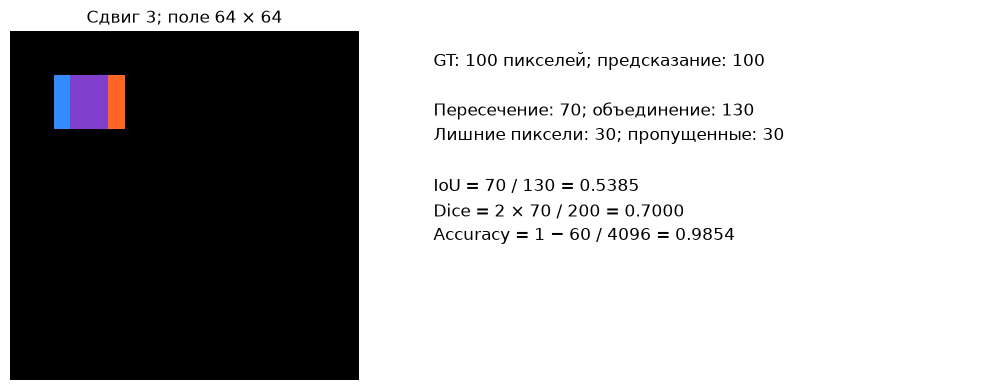

In [ ]:
stand_controls(overlap_demo,
    dx=widgets.IntSlider(value=3,min=0,max=14,description='Сдвиг, px'),
    background=widgets.SelectionSlider(options=[32,48,64,80,96],value=64,description='Поле, px'))

### Получите результат · 4 опыта

1. При поле 64 подберите сдвиг, который даёт **IoU=1/3 и Dice=1/2**. До запуска вычислите
   пересечение, объединение, лишние и пропущенные пиксели. Проверьте все четыре числа.
2. Сохраните найденный сдвиг. Найдите **минимальное доступное поле с accuracy ≥ 0.98**.
   Какие две метрики не изменились? Почему accuracy теперь выглядит лучше?
3. Найдите **два разных сдвига с IoU=Dice=0**. Сравните accuracy и фактическое расстояние
   между масками. Какую информацию эти метрики здесь потеряли?
4. Возьмите два опыта: сдвиги 0 и 10, поле 64. Сначала усредните IoU и Dice отдельно.
   Затем примените `2·mean(IoU)/(1+mean(IoU))`. Совпало ли это с mean(Dice)? Объясните.

| Опыт | Прогноз до запуска | Настройки | Полученные числа | Объяснение |
|---|---|---|---|---|
| 1 | … | … | … | … |
| 2 | … | … | … | … |
| 3 | … | … | … | … |
| 4 | … | … | … | … |

## 2. MATCH IoU: какая маска считается найденным объектом

**Цель:** проследить создание пар «предсказание → GT».

### Теория перед опытом

В объектной сегментации нужно восстановить отдельные экземпляры, а не только общий
силуэт переднего плана. Пусть есть $N$ предсказанных масок $P_i$ и $M$ эталонных $G_j$.
Матрица $A_{ij}=\mathrm{IoU}(P_i,G_j)$ имеет размер $N\times M$.
**MATCH IoU**, или $\tau$, задаёт минимальное пересечение для допустимой пары: $A_{ij}\ge\tau$.
Confidence (score) — оценка уверенности самой модели; IoU вычисляется по известной разметке.

В этой работе используется жадное сопоставление одного класса:

1. Обработать предсказания по убыванию confidence.
2. Для очередного предсказания выбрать среди **ещё свободных** GT наибольший IoU,
   удовлетворяющий порогу; если такого GT нет, оставить предсказание без пары.
3. Занять выбранный GT: повторно использовать его нельзя. После всех предсказаний
   подсчитать пары и оставшиеся без пары маски.

$$TP=\text{число пар},\qquad FP=N-TP,\qquad FN=M-TP.$$

**TP** — найденный экземпляр; **FP** — предсказание без пары, включая дубликат;
**FN** — эталонный экземпляр без пары. Зелёная ячейка лишь допускает соответствие:
она ещё не гарантирует, что алгоритм выберет именно его.

**Foreground IoU** сначала объединяет все предсказания в $P_{fg}=\bigcup_i P_i$,
а все GT — в $G_{fg}=\bigcup_j G_j$, затем считает обычный IoU этих двух множеств.
ID при этом исчезают: показатель оценивает общий силуэт, но не разделение людей.
Matching — этап **оценки** с GT; его порог не является порогом NMS.

### Как читать стенд

Выберите случай и порог **MATCH IoU**.
Сдвиг действует только в случае «Сдвинутые маски». Порог **не меняет пиксели** — он меняет
допустимые пары и TP/FP/FN. Поэтому неизменный рисунок масок при изменении порога ожидаем.

Слева GT1 и GT2, в центре предсказания P1… с confidence. Справа — матрица IoU:
зелёная ячейка проходит порог, надпись «ПАРА» означает реально выбранное соответствие.
Ниже показан порядок обработки. Сначала рассматривается более уверенное предсказание;
каждому GT достаётся не более одного. При равном IoU выбирается меньший свободный номер GT.

У объединённой маски IoU с каждым из двух равных GT — ровно 0.5. При порогах выше 0.5
результат одинаков; это свойство примера. Сравните **0.50 и 0.55**, затем смените случай.

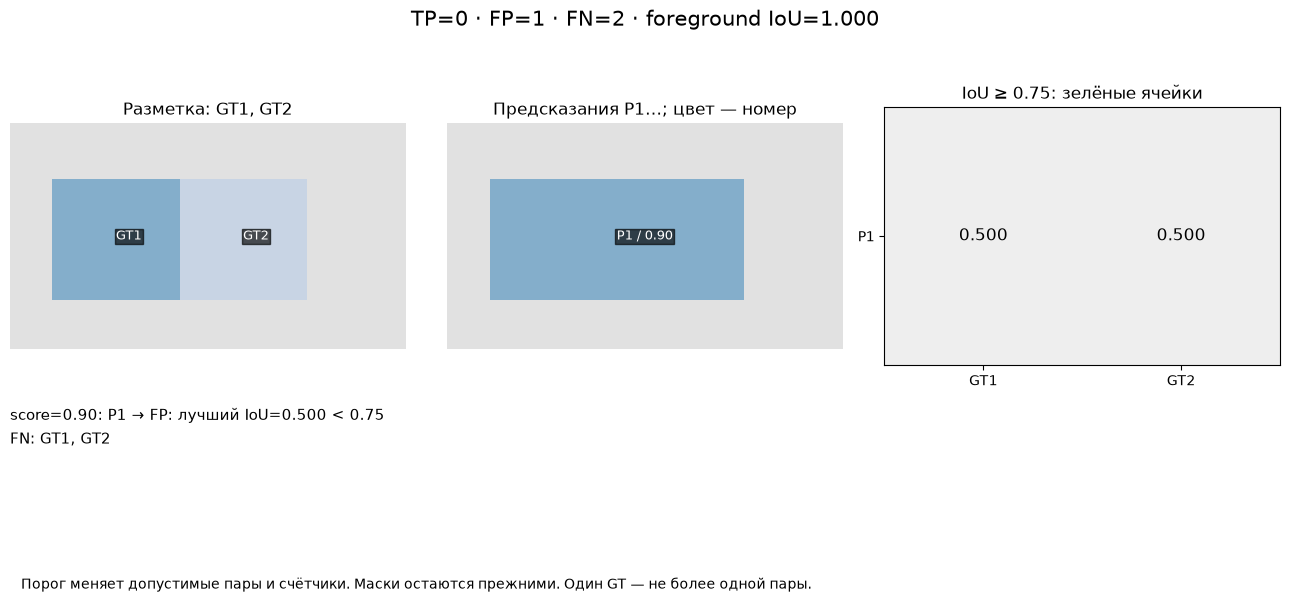

In [ ]:
MATCH_CONTROLS={
    'mode':widgets.Dropdown(options=[('Слитая маска','merge'),('Две точные маски','separate'),('Сдвинутые маски','shift'),('Дубликат с разными score','duplicate')],value='merge',description='Случай'),
    'match_iou':widgets.SelectionSlider(options=[(f'{n/100:.2f}',n/100) for n in range(10,101,5)],value=.75,description='MATCH IoU'),
    'shift':widgets.IntSlider(value=4,min=0,max=10,description='Сдвиг, px')}
MATCH_CONTROLS['shift'].disabled=True
def update_shift_control(change):
    MATCH_CONTROLS['shift'].disabled=change['new']!='shift'
MATCH_CONTROLS['mode'].observe(update_shift_control,names='value')
stand_controls(merge_demo,**MATCH_CONTROLS)

### Получите результат · 4 опыта

1. Для слитой маски заполните пары и TP/FP/FN при **0.50 и 0.55**. Почему при 0.50
   обе ячейки зелёные, а реальная пара только одна? Что произошло с foreground IoU?
2. Выберите сдвинутые маски, сдвиг **4**. Вычислите IoU соответствующей пары по ширинам
   пересечения и объединения. Найдите соседние доступные пороги, между которыми TP меняется с 2 на 0.
3. Выберите дубликат, порог **0.75**. По confidence заранее выпишите порядок P1/P2/P3
   и назначение каждой маски. Объясните, почему предсказание с IoU=1 может стать FP.
4. При пороге **0.75** сравните слитую и две точные маски. Получите одинаковый
   foreground IoU при разном числе TP. Какой вывод об оценке экземпляров отсюда следует?

| Опыт | Прогноз пар | Случай / порог / сдвиг | TP / FP / FN | Почему так |
|---|---|---|---|---|
| 1 | … | … | … | … |
| 2 | … | … | … | … |
| 3 | … | … | … | … |
| 4 | … | … | … | … |

## 3. Дробная координата: один шаг RoIAlign

**Цель:** вручную воспроизвести билинейную выборку.

### Теория перед опытом

После backbone изображение представлено сеткой признаков. Граница найденного региона
**RoI (region of interest)** при переносе на эту сетку обычно попадает между узлами.
Округление координат теряет точное положение границы, что особенно заметно в масках.

**RoIAlign получает карту признаков и рамки регионов**. Для каждой рамки он формирует
сетку признаков заданного размера; число каналов сохраняется. Внутри каждой выходной
ячейки берутся дробные точки, значения в них вычисляются билинейной интерполяцией
и усредняются. Затем признаки региона поступают в масочную голову Mask R-CNN.
Стенд увеличивает **одну точку одного канала** этого вычисления.

Значения $f_{00},f_{10},f_{01},f_{11}$ — признаки четырёх соседних узлов, а не
вероятности маски. Локальные $x,y\in[0,1]$ измеряются от верхнего левого узла:
$x$ растёт вправо, $y$ — вниз. Сначала интерполируем две строки, затем результат по вертикали:

$$\begin{aligned}
t(x)&=(1-x)f_{00}+xf_{10},\\
b(x)&=(1-x)f_{01}+xf_{11},\\
F(x,y)&=(1-y)t(x)+yb(x).
\end{aligned}$$

Отсюда веса четырёх узлов: $(1-x)(1-y)$, $x(1-y)$, $(1-x)y$, $xy$.
Внутри ячейки они неотрицательны и дают в сумме 1, поэтому результат лежит между
минимальным и максимальным значениями узлов. Вклад изменения одного узла равен
его весу, умноженному на изменение признака. Ближайший узел, напротив, меняется
скачком при пересечении границы округления. Это сравнение выборок, а не полная
реализация слоя RoIPool.

Размеры входов и выходов: [документация RoIAlign](https://docs.pytorch.org/vision/stable/generated/torchvision.ops.roi_align.html).

### Как читать стенд

Ползунки x и y задают точку внутри
ячейки карты признаков. Третий ползунок меняет значение правого нижнего узла f₁₁.
Верхние узлы равны 2 и 4, нижний левый — 6. Под графиком обновляются **формула,
четыре численных слагаемых и двухэтапная интерполяция**. Возле узлов указаны их веса.

Ближайший узел выбирается с границей 0.5; при равенстве выбирается правый/нижний.
Стенд показывает одну выборку, а не всю RoIAlign: в реальном слое есть несколько
точек выборки, ячеек и каналов.

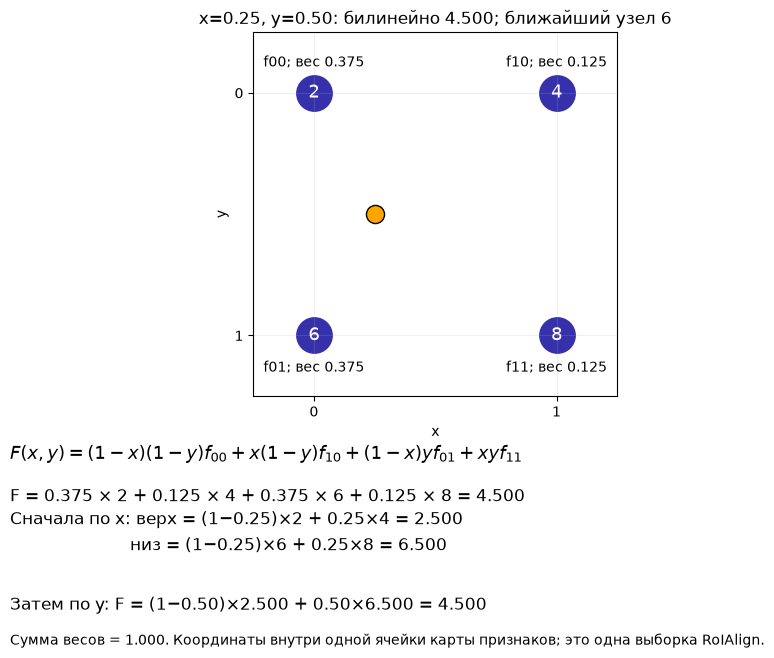

In [ ]:
stand_controls(roi_demo,
    x=widgets.FloatSlider(value=.25,min=0,max=1,step=.05,description='Координата x',readout_format='.2f'),
    y=widgets.FloatSlider(value=.5,min=0,max=1,step=.05,description='Координата y',readout_format='.2f'),
    f11=widgets.IntSlider(value=8,min=0,max=14,description='Узел f₁₁'))

### Получите результат · 4 опыта

1. При **x=0.25, y=0.50, f₁₁=8** вручную вычислите четыре веса и четыре вклада.
   Проверьте сумму весов и конечное значение по формуле под графиком.
2. При f₁₁=8 найдите **две разные точки со значением F=6**. Подтвердите обе
   подстановкой. Единственны ли координаты, если известно только значение признака?
3. При y=0.25, f₁₁=8 сравните **x=0.45 и x=0.55**. На сколько меняются билинейный
   результат и ближайший узел? Свяжите разницу с округлением координат.
4. Верните x=0.25, y=0.50 и измените **f₁₁ с 8 на 10**. До запуска предскажите
   прибавку как «вес узла × изменение узла». Затем найдите точку, где такое изменение не влияет на F.

| Опыт | Расчёт до запуска | x / y / f₁₁ | F и ближайший узел | Объяснение |
|---|---|---|---|---|
| 1 | … | … | … | … |
| 2 | … | … | … | … |
| 3 | … | … | … | … |
| 4 | … | … | … | … |

## 4. Три прототипа: собрать разные экземпляры одним базисом

**Цель:** получить нужный объект коэффициентами, а затем отделить их действие от порога и crop.

### Теория перед опытом

Идея прототипов — вычислить для изображения общий набор из $K$ пространственных карт
размера $H\times W$, а для каждого найденного объекта предсказать свой вектор из $K$
коэффициентов. Прототипы общие, коэффициенты разные — так из одних карт получаются
маски разных экземпляров. В настоящей сети и карты, и коэффициенты вычисляются
по изображению; здесь карты заданы вручную, а коэффициенты выбираете вы.

Для объекта $i$ и пикселя $(u,v)$:

$$\begin{aligned}
z_i(u,v)&=\sum_{k=1}^{K}c_{ik}P_k(u,v),\\
\sigma(z)&=\frac{1}{1+e^{-z}},\\
q_i(u,v)&=B_i(u,v)\,\sigma(z_i(u,v)),\\
\widehat M_i(u,v)&=\mathbf{1}[q_i(u,v)\ge t].
\end{aligned}$$

$z$ — **логит**, вещественное число до sigmoid; $\sigma(z)$ — вероятность от 0 до 1.
$B_i$ равно 1 внутри рамки и 0 снаружи (**crop**, обрезка), $t$ — порог пикселя,
$\mathbf{1}[\cdot]$ возвращает 1 при выполнении условия. Sigmoid применяется **после суммы**.
Отрицательный коэффициент вычитает карту признаков; это не отрицательная вероятность.
Положительный логит даёт вероятность выше 0.5, нулевой — ровно 0.5.

Внутри рамки при $0<t<1$ условие можно переписать как
$z\ge\ln\!\left(t/(1-t)\right)$. Так влияние порога можно предсказать без перебора.
За рамкой вероятность в стенде всегда нулевая: при положительном пороге коэффициенты
не вернут обрезанную часть. Повышение порога может только убирать пиксели при фиксированных
коэффициентах; изменение коэффициентов перестраивает саму карту вероятностей.

Общие прототипы и коэффициенты используются в [YOLACT](https://github.com/dbolya/yolact)
и сегментационной голове [Ultralytics Segment](https://docs.ultralytics.com/reference/nn/modules/head/#ultralytics.nn.modules.head.Segment).
Здесь воспроизведён принцип сборки; масштабирование масок и детали постобработки упрощены.

### Как читать стенд

Показаны **три пространственные карты**: P₁ содержит общую грубую форму и отрицательный фон,
P₂ различает левую и правую фигуры, P₃ выделяет области между ногами. Это вещественные признаки,
а не готовые вероятности. Каждый коэффициент управляется отдельно.

Вычисление: `z=c₁P₁+c₂P₂+c₃P₃ → sigmoid(z) → crop → p≥порога`.
Выбор «Цель» меняет только GT для сравнения. Рамка, коэффициенты и порог меняют предсказание.
В нижнем правом рисунке зелёный — верные пиксели, красный — лишние, оранжевый — пропущенные.
Точки A/B/C/D позволяют проверить вычисление для отдельного пикселя.

В A значения прототипов (4,4,0), в B — (4,4,12), в C — (4,−4,0), в D — (−4,0,0).
Начальная настройка оставляет лишние пиксели между ногами — исправьте её.
Это учебный базис, а не веса настоящего YOLO или YOLACT.

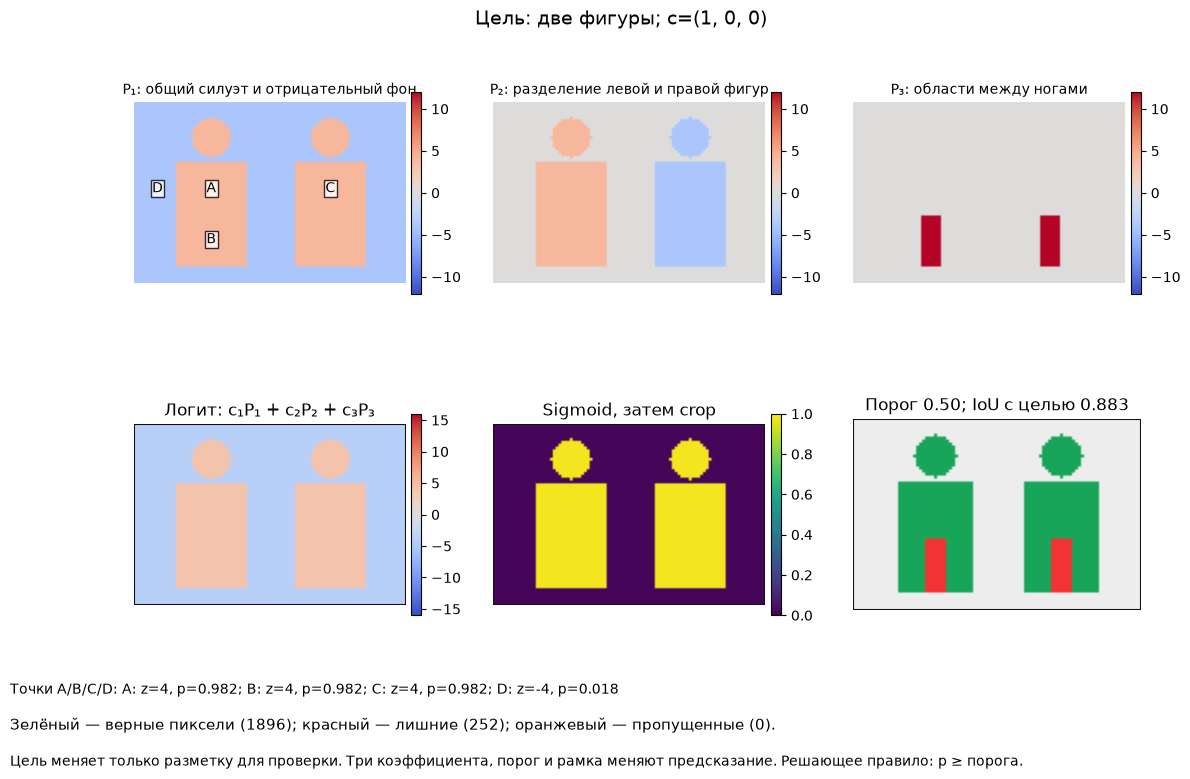

In [ ]:
stand_controls(prototype_demo,
    first=widgets.FloatSlider(value=1,min=-2,max=2,step=.5,description='Коэффициент c₁'),
    second=widgets.FloatSlider(value=0,min=-2,max=2,step=.5,description='Коэффициент c₂'),
    third=widgets.FloatSlider(value=0,min=-2,max=2,step=.5,description='Коэффициент c₃'),
    threshold=widgets.FloatSlider(value=.5,min=.05,max=.95,step=.05,description='Порог пикселя',readout_format='.2f'),
    target=widgets.Dropdown(options=[('Две фигуры','both'),('Левая фигура','left'),('Правая фигура','right')],value='both',description='Цель'),
    crop=widgets.Dropdown(options=[('Вся сцена','full'),('Левая фигура целиком','left'),('Узкая рамка слева','narrow')],value='full',description='Рамка'))

### Получите результат · 5 опытов

1. Цель «Две фигуры», рамка «Вся сцена», порог 0.50. Зафиксируйте **c₁=1, c₂=0**
   и подберите c₃ так, чтобы получить **IoU=1**. Объясните знак через логит в точке B.
2. При рамке «Вся сцена», пороге 0.50 и c₁=1 получите **IoU=1 сначала для левой,
   затем для правой фигуры**. Менять рамку нельзя. Запишите оба вектора коэффициентов и их связь.
3. Задайте **c=(1,1.5,−1)**, цель «Левая фигура», рамка «Вся сцена».
   Вручную вычислите z и sigmoid(z) в A/B/C/D. Выведите интервал порогов с IoU=1;
   проверьте пороги 0.10 и 0.15. Почему более низкий порог вернул лишнюю фигуру?
4. С тем же c и целью выберите «Узкая рамка слева». Можно ли вернуть отсечённые
   пиксели изменением коэффициентов или порога? Сравните с рамкой, охватывающей левую фигуру целиком.
5. В точке B для **c=(1,1.5,−1)** сравните `sigmoid(c₁P₁+c₂P₂+c₃P₃)`
   и `c₁·sigmoid(P₁)+c₂·sigmoid(P₂)+c₃·sigmoid(P₃)`. Второй результат может превышать 1.
   Объясните, почему перестановка операций не является альтернативной реализацией той же маски.

| Опыт | Ручной прогноз | c₁ / c₂ / c₃ / порог / рамка | IoU и ошибки | Объяснение |
|---|---|---|---|---|
| 1 | … | … | … | … |
| 2 | … | … | … | … |
| 3 | … | … | … | … |
| 4 | … | … | … | … |
| 5 | … | … | … | … |

## 5. Реальная модель: объекты и пиксели — разные решения

**Цель:** по таблице объяснить, что изменил каждый порог.

### Теория перед опытом

Для кандидата Mask R-CNN возвращает рамку, класс, **score всего объекта** и
**вероятности пикселей маски**. Это разные величины: высокий score не гарантирует
точную границу силуэта. Если $s_i$ — score, а $p_i(u,v)$ — вероятность пикселя, то
кандидата оставляем при $s_i\ge t_{conf}$, а его бинарная маска равна
$\widehat M_i(u,v)=\mathbf{1}[p_i(u,v)\ge t_{pixel}]$.

В пайплайне встречаются четыре порога. Одинаковое число 0.50 у них не означает
одинакового действия:

| Порог | Что сравнивается | Что меняет | Нужна GT? |
|---|---|---|---|
| Confidence | Score объекта с порогом | Оставляет или удаляет целый кандидат | Нет |
| Пикселя | Вероятность каждого пикселя с порогом | Форму и площадь маски оставшегося кандидата | Нет |
| NMS IoU | IoU предсказанных рамок между собой | Подавляет менее уверенные перекрывающиеся кандидаты | Нет |
| MATCH IoU | IoU предсказанной маски с эталонной | Допустимые пары и TP/FP/FN при оценке | Да |

Здесь **NMS работает с рамками**, а matching — с масками. NMS уже выполнен внутри
модели; ползунки работают с его сохранённым результатом и не восстанавливают
подавленные кандидаты. GT не участвует в построении предсказания, только в оценке.

При повышении порога пикселя и фиксированном confidence площадь каждой маски
не растёт. Однако IoU может как вырасти (убрали лишний фон), так и упасть
(потеряли часть объекта). Поэтому меньше пикселей не означает автоматически лучше.
Площадь маски в таблице — число единичных пикселей; «лучший IoU» ищется среди всех GT,
а назначенная пара — только среди ещё свободных, как в стенде 2.

### Как читать стенд

Подготовка ниже один раз
запускает две предобученные модели на train-изображении. Затем используются сохранённые выходы.
**Confidence** удаляет целые экземпляры, **порог пикселя** меняет их форму.
MATCH IoU здесь фиксирован на 0.50, NMS уже выполнен с порогом 0.50.

В таблице ID предсказания сохраняется при изменении confidence. Сравнивайте площадь,
лучший IoU и назначенную GT-пару. Пустая маска всё ещё может быть кандидатом и считаться FP.
В заголовках рисунков показаны счётчики и foreground IoU; рамки — контроль формы той же модели.

In [ ]:
split=prepare_data(ROOT)
print({k:len(v) for k,v in split.items()})
image,id_map=read_sample(split['train'][0])
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].imshow(image);axes[0].set_title('Исходное изображение')
axes[1].imshow(id_map,cmap='tab20',interpolation='nearest');axes[1].set_title('Целочисленные ID, 0 — фон')
for ax in axes:ax.axis('off')
plt.tight_layout();plt.show()
print('ID в этом изображении:',np.unique(id_map))

In [ ]:
DEMO_ITEM=split['train'][0]
mask_model=make_maskrcnn()
MASK_PRED=predict_maskrcnn(mask_model,DEMO_ITEM)
del mask_model;gc.collect()
if torch.cuda.is_available():torch.cuda.empty_cache()
yolo_model=YOLO(str(weight_path('yolo11n_seg')))
YOLO_PRED=predict_yolo(yolo_model,DEMO_ITEM)
del yolo_model;gc.collect()
if torch.cuda.is_available():torch.cuda.empty_cache()

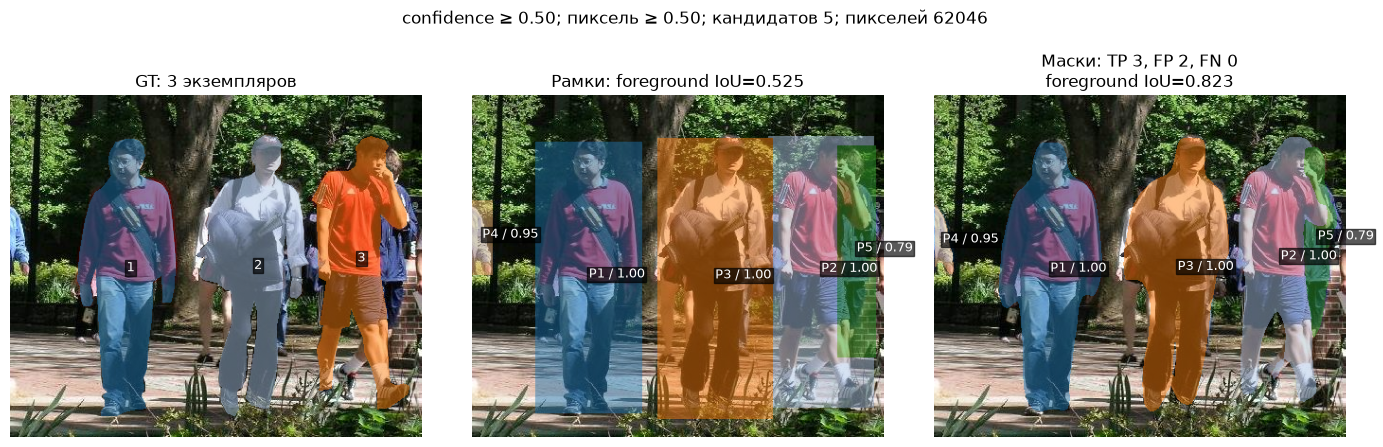

,ID,score,площадь,лучший IoU,пара,статус
0,P1,0.9993,19940,0.9017,GT1,TP
1,P2,0.9986,17319,0.8597,GT3,TP
2,P3,0.9985,20091,0.8492,GT2,TP
3,P4,0.9545,927,0.0000,—,FP
4,P5,0.7908,3769,0.0291,—,FP


Формы масок и таблица пересчитаны из сохранённых вероятностей. Модель и NMS повторно не запускались. MATCH IoU = 0.50.


In [ ]:
def show_thresholds(confidence=.5,mask_threshold=.5):
    threshold_demo(DEMO_ITEM,MASK_PRED,confidence,mask_threshold)
stand_controls(show_thresholds,
    confidence=widgets.FloatSlider(value=.5,min=.05,max=.95,step=.05,description='Confidence',readout_format='.2f'),
    mask_threshold=widgets.FloatSlider(value=.5,min=.1,max=.9,step=.1,description='Порог пикселя',readout_format='.2f'))

### Получите результат · 4 опыта

1. Порог пикселя 0.50, confidence сначала **0.25**, затем **0.75**. По score заранее
   выпишите ID, которые исчезнут. Проверьте число кандидатов и изменение TP/FP/FN.
2. Confidence 0.25, порог пикселя **0.30 и 0.70**. Докажите по таблице, что набор
   кандидатов тот же, а площади изменились. Найдите изменение IoU или GT-пары для конкретного ID.
3. При пороге пикселя 0.50 найдите **наибольший доступный confidence**, сохраняющий
   столько же TP, сколько при 0.05. Сколько FP удалось убрать? Не требуйте, чтобы TP равнялся числу GT.
4. При confidence 0.25 и пороге пикселя 0.50 сравните foreground IoU **рамок и масок**.
   Укажите конкретную область фона или просвет, который исключает маска. Запишите назначение
   всех четырёх порогов: confidence, пикселя, NMS, matching.

| Опыт | Прогноз по таблице | Настройки | ID / площади / TP, FP, FN | Объяснение |
|---|---|---|---|---|
| 1 | … | … | … | … |
| 2 | … | … | … | … |
| 3 | … | … | … | … |
| 4 | … | … | … | … |

## 6. Две архитектуры: сравнить конкретные ошибки

**Цель:** сделать проверяемое наблюдение по одному кадру и сформулировать гипотезу для val.

### Теория перед опытом

У **Mask R-CNN** признаки выбранного региона проходят через RoIAlign и масочную
голову: для каждого региона получается своя пространственная маска. У **YOLO11-seg**
общие карты прототипов комбинируются с коэффициентами конкретного обнаруженного
объекта. Стенды 3 и 4 показывают отдельные операции этих двух способов построения маски.

После единого matching посчитаем качество найденных **экземпляров**:

$$\mathrm{precision}=\frac{TP}{TP+FP},\qquad
\mathrm{recall}=\frac{TP}{TP+FN}.$$

Precision отвечает «какая доля выданных объектов подтверждена разметкой?», recall —
«какая доля размеченных объектов найдена?». В таблице $N=TP+FP$ — число оставшихся
предсказаний. При нулевом знаменателе код этой работы возвращает 0.
Foreground IoU дополнительно оценивает объединённый силуэт, теряя ID экземпляров.

Одна настройка confidence даёт **одну рабочую точку** precision/recall.
**AP** учитывает ранжирование предсказаний по score на всём оценочном наборе и
обобщает кривую precision–recall. В основной работе AP50 и AP75 считаются отдельно
при порогах matching 0.50 и 0.75, с интерполяцией по 101 уровню recall.
Числа 50 и 75 относятся к IoU, а не к confidence; AP50 не равен precision при confidence 0.50.

Scores разных моделей не обязаны иметь одинаковый смысл: значение 0.8 само по себе
не обещает 80% верных масок. Порог выбирают на **val**, а итог проверяют на **test**
после фиксации решения. Кадр стенда взят из train для изучения ошибок, поэтому по нему
нельзя объявлять победителя. Нужны общая выборка, единый оценщик и разбор условий:
у моделей различаются backbone, предобработка и размер. Наблюдаемая разница не
доказывает преимущество одной только масочной головы.

### Как читать стенд

Mask R-CNN строит маску региона, YOLO11-seg — маску из прототипов и коэффициентов.
Обе модели уже запущены. Confidence настраивается отдельно: одинаковые числа не гарантируют
одинаковой калибровки. Общий MATCH IoU управляет только оценкой пар.

Порог маски Mask R-CNN фиксирован на 0.50. YOLO через этот API возвращает уже бинарные маски,
поэтому дополнительный ползунок вероятности к ним неприменим. Таблица показывает **этот кадр**,
а не AP всего набора. Номера и цвета предсказаний между моделями не согласованы.

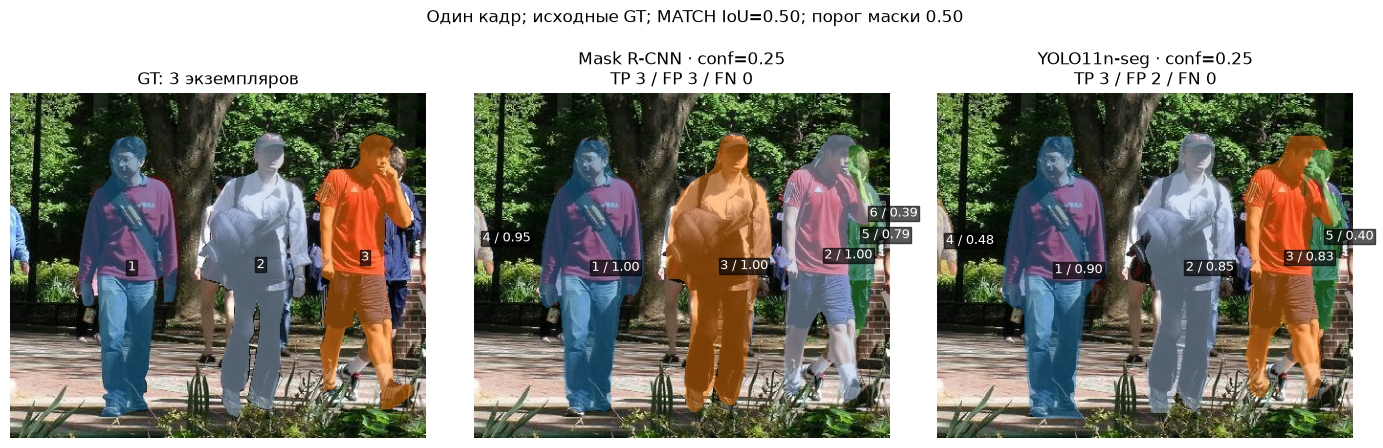

,модель,conf,N,TP,FP,FN,precision,recall,foreground IoU
0,Mask R-CNN,0.25,6,3,3,0,0.5,1.0,0.8182
1,YOLO11n-seg,0.25,5,3,2,0,0.6,1.0,0.7930


Порог сопоставления меняет TP/FP/FN, но не foreground IoU. Номера и цвета экземпляров между моделями не согласованы.


In [ ]:
def show_comparison(conf_mask=.25,conf_yolo=.25,match_iou=.5):
    real_comparison(DEMO_ITEM,MASK_PRED,YOLO_PRED,conf_mask,conf_yolo,match_iou)
stand_controls(show_comparison,
    conf_mask=widgets.FloatSlider(value=.25,min=.05,max=.95,step=.05,description='Mask R-CNN conf',readout_format='.2f'),
    conf_yolo=widgets.FloatSlider(value=.25,min=.05,max=.95,step=.05,description='YOLO conf',readout_format='.2f'),
    match_iou=widgets.SelectionSlider(options=[('0.50',.5),('0.75',.75)],value=.5,description='MATCH IoU'))

### Получите результат · 4 опыта

1. Оба confidence 0.25. Сравните MATCH IoU **0.50 и 0.75** для обеих моделей.
   Запишите N, TP/FP/FN и foreground IoU. Какие величины обязаны остаться неизменными и почему?
2. Верните MATCH IoU 0.50. Для каждой модели отдельно увеличьте confidence от 0.05
   до **наибольшего значения, сохраняющего исходный TP**. Сравните полученные precision/recall
   и пороги. Можно ли считать одинаковый confidence достаточным условием честного сравнения?
3. Верните оба confidence 0.25. Выберите одного GT-человека и сравните границы его масок.
   Укажите конкретную область: ноги, край одежды, перекрытие. Классифицируйте наблюдение
   как ошибку формы, пропуск, лишний экземпляр или возможную неполноту разметки; приложите фрагмент кадра.
4. Сформулируйте **одну проверяемую гипотезу** для ноутбука 02: ожидаемая разница,
   метрика, какие val-кадры нужны и какой результат опровергнет гипотезу. Почему этого кадра недостаточно?

| Опыт | Прогноз / гипотеза | Две настройки confidence и MATCH IoU | Наблюдение | Вывод и ограничение |
|---|---|---|---|---|
| 1 | … | … | … | … |
| 2 | … | … | … | … |
| 3 | … | … | … | … |
| 4 | … | … | … | … |

### К основной работе

Сохраните заполненные таблицы и объяснения. В ноутбуке 02 проверьте выбранную гипотезу
на общей val-выборке, затем дообучите обе модели и оцените их единым оценщиком.